In [15]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

base_path = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

# Region
LAT_MIN, LAT_MAX = 25, 45
LON_MIN, LON_MAX = -50, -30

In [16]:
# Flat-linear model
def flat_then_linear(x, c, m, x_break):
    return np.where(
        x < x_break,
        c,
        c + m * (x - x_break)
    )

In [17]:
def flat_piecewise_variable_analysis(
    variable_token,
    variable_label,
    units,
    start_year=1958,
    end_year=2023,
    break_guess=1980
):

    # Find files
    files = sorted(base_path.rglob(f"*{variable_token}*.nc"))
    print(f"\nFound {len(files)} files for {variable_label}")

    records = []

    for f in files:
        try:
            # Extract year/month
            match = re.search(
                rf"ORAS5_(\d{{4}})_(\d{{2}}).*{variable_token}",
                f.name
            )

            if match is None:
                continue

            year = int(match.group(1))
            month = int(match.group(2))

            ds = xr.open_dataset(f)

            # First variable in dataset
            var_name = list(ds.data_vars)[0]
            var = ds[var_name]

            # Remove depth dimension if present
            for depth_dim in ["deptht", "depth", "lev"]:
                if depth_dim in var.dims:
                    var = var.isel({depth_dim: 0})

            # Coordinates
            if "nav_lat" in ds:
                lat = ds["nav_lat"]
                lon = ds["nav_lon"]
            elif "latitude" in ds:
                lat = ds["latitude"]
                lon = ds["longitude"]
            else:
                print(f"Skipping {f.name}: no recognised lat/lon coordinates")
                continue

            # Convert longitude
            lon = xr.where(lon > 180, lon - 360, lon)

            # Box mask
            box_mask = (
                (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                (lon >= LON_MIN) & (lon <= LON_MAX)
            )

            # Apply mask
            var_box = var.where(box_mask)

            # Convert SST to C if needed
            if variable_token == "sst":
                if float(var_box.mean(skipna=True)) > 100:
                    var_box = var_box - 273.15

            # Mean over box
            monthly_mean = float(var_box.mean(skipna=True))

            records.append({
                "year": year,
                "month": month,
                variable_label: monthly_mean
            })

            ds.close()

        except Exception as e:
            print(f"Skipping {f.name}: {e}")

    # Dataframe
    df = pd.DataFrame(records)

    annual_df = (
        df
        .groupby("year", as_index=False)[variable_label]
        .mean()
        .sort_values("year")
    )

    # Year range
    annual_df = annual_df[
        (annual_df["year"] >= start_year) &
        (annual_df["year"] <= end_year)
    ]

    # Remove NaNs and unrealistic fill values
    annual_df = annual_df.replace([np.inf, -np.inf], np.nan)
    annual_df = annual_df.dropna()

    annual_df = annual_df[
        np.abs(annual_df[variable_label]) < 1e10
    ]

    years_clean = annual_df["year"].values.astype(float)
    values_clean = annual_df[variable_label].values.astype(float)

    print(annual_df)

    c_guess = np.mean(values_clean[years_clean < break_guess])
    m_guess = 0.01

    p0 = [c_guess, m_guess, break_guess]

    lower_bounds = [
        np.min(values_clean) - abs(np.min(values_clean)),
        -np.inf,
        start_year + 5
    ]

    upper_bounds = [
        np.max(values_clean) + abs(np.max(values_clean)),
        np.inf,
        end_year - 5
    ]

    # Fit model
    popt, pcov = curve_fit(
        flat_then_linear,
        years_clean,
        values_clean,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=100000
    )

    c_fit, m_fit, break_fit = popt

    # Errors
    perr = np.sqrt(np.diag(pcov))
    c_err, m_err, break_err = perr

    # Predictions
    y_hat = flat_then_linear(years_clean, c_fit, m_fit, break_fit)

    # Residuals
    residuals = values_clean - y_hat
    rss = np.sum(residuals**2)
    tss = np.sum((values_clean - np.mean(values_clean))**2)
    r2 = 1 - rss / tss

    print(f"\nOptimised breakpoint year: {break_fit:.2f} ± {break_err:.2f}")
    print(f"Flat baseline: {c_fit:.5f} ± {c_err:.5f} {units}")
    print(f"Post-break slope: {m_fit:.5f} ± {m_err:.5f} {units}/year")
    print(f"R²: {r2:.4f}")

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        years_clean,
        values_clean,
        linewidth=1.5,
        label=f"Observed {variable_label}"
    )

    plt.plot(
        years_clean,
        y_hat,
        linewidth=2.5,
        label="Flat-then-linear fit"
    )

    plt.axvline(
        break_fit,
        linestyle="--",
        alpha=0.8,
        label=f"Breakpoint = {break_fit:.1f}"
    )

    plt.title(f"Flat-Then-Linear Fit on Annual Mean {variable_label}")
    plt.xlabel("Year")
    plt.ylabel(f"{variable_label} ({units})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return annual_df, popt, pcov

In [18]:
VARIABLES = [
    {
        "token": "sst",
        "label": "SST",
        "units": "°C",
        "break_guess": 1975
    },
    {
        "token": "so_salinity",
        "label": "Salinity",
        "units": "PSU",
        "break_guess": 1975
    },
    {
        "token": "v_meridional",
        "label": "V Current",
        "units": "m/s",
        "break_guess": 1975
    },
    {
        "token": "u_zonal",
        "label": "U Current",
        "units": "m/s",
        "break_guess": 1975
    },
    {
        "token": "thetao_potential_temperature",
        "label": "Potential Temperature",
        "units": "°C",
        "break_guess": 1975
    },
    {
        "token": "net_downward_heat_flux",
        "label": "Net Downward Heat Flux",
        "units": "W/m²",
        "break_guess": 1975
    }
]


Found 798 files for SST
    year        SST
0   1958  20.584044
1   1959  20.410537
2   1960  20.945526
3   1961  20.938600
4   1962  20.656470
..   ...        ...
60  2018  21.357321
61  2019  21.102062
62  2020  21.271212
63  2021  21.413530
64  2022  20.390382

[65 rows x 2 columns]

Optimised breakpoint year: 1980.37 ± 5.85
Flat baseline: 20.50060 ± 0.04874 °C
Post-break slope: 0.01493 ± 0.00298 °C/year
R²: 0.4575


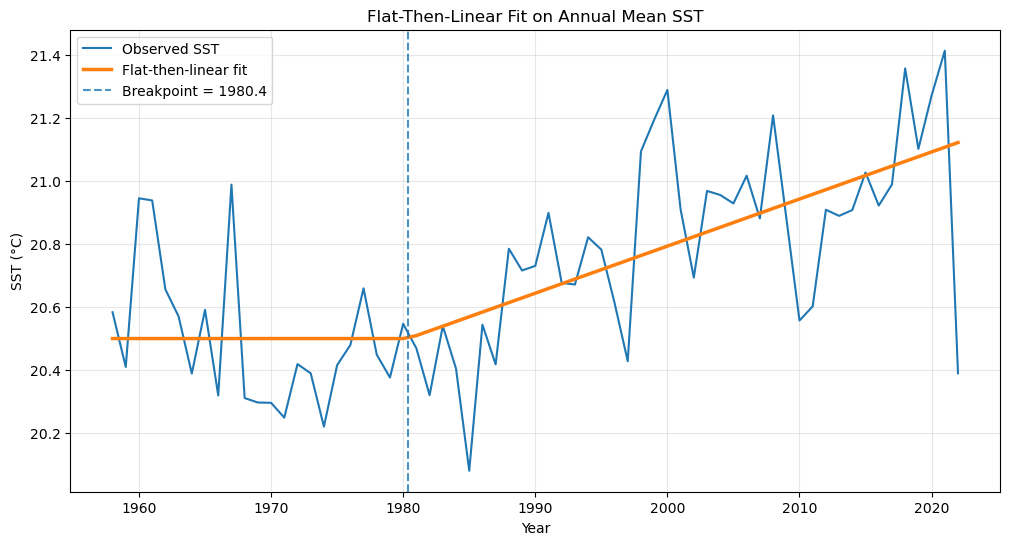


Found 798 files for Salinity
    year   Salinity
0   1958  36.332911
1   1959  36.386271
2   1960  36.406404
3   1961  36.472236
4   1962  36.451410
..   ...        ...
56  2014  36.440841
57  2015  36.432220
58  2016  36.451520
59  2017  36.507505
60  2018  36.538486

[61 rows x 2 columns]

Optimised breakpoint year: 1973.00 ± 9.96
Flat baseline: 36.41294 ± 0.01609 PSU
Post-break slope: 0.00250 ± 0.00071 PSU/year
R²: 0.2752


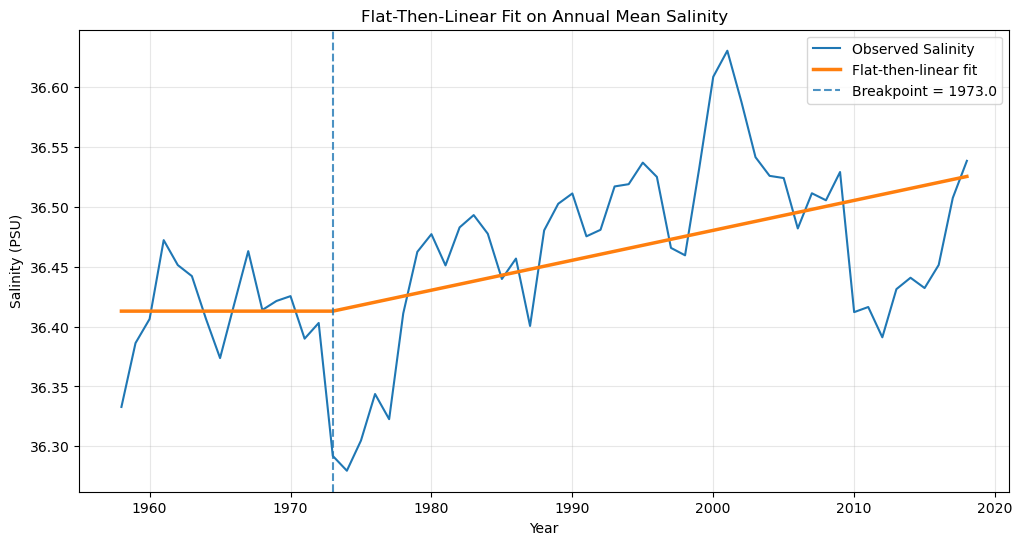


Found 798 files for V Current
Skipping ORAS5_1979_02_v_meridional_boxed.nc: no recognised lat/lon coordinates
    year  V Current
0   1958  -0.001438
1   1959  -0.002055
2   1960  -0.002936
3   1961  -0.002971
4   1962  -0.002158
..   ...        ...
56  2014  -0.002454
57  2015  -0.002272
58  2016  -0.002088
59  2017  -0.002897
60  2018  -0.003811

[61 rows x 2 columns]

Optimised breakpoint year: 1965.00 ± 80.15
Flat baseline: -0.00261 ± 0.00034 m/s
Post-break slope: -0.00001 ± 0.00001 m/s/year
R²: 0.0094


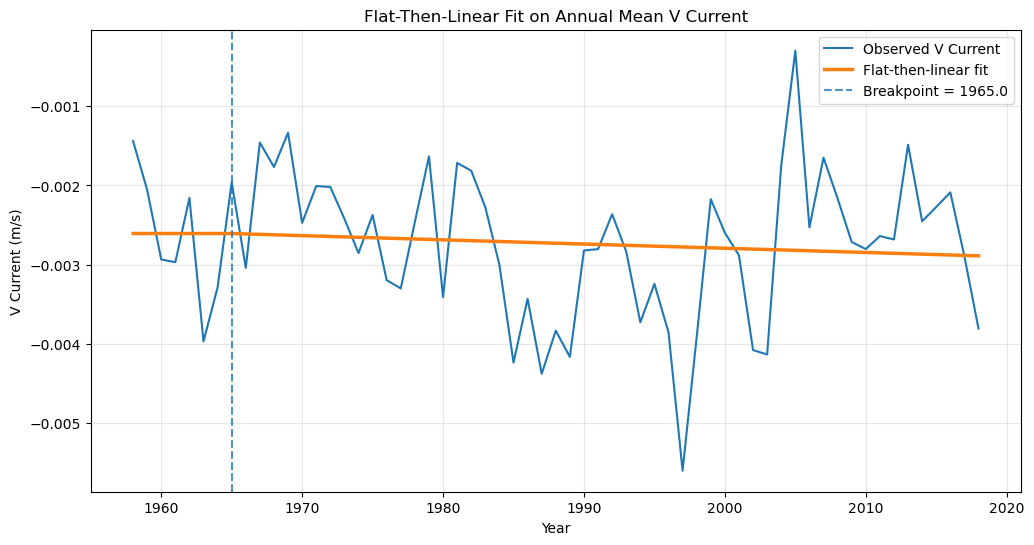


Found 798 files for U Current
    year  U Current
0   1958   0.012928
1   1959   0.013477
2   1960   0.013981
3   1961   0.013080
4   1962   0.012519
..   ...        ...
56  2014   0.011360
57  2015   0.010933
58  2016   0.013246
59  2017   0.010961
60  2018   0.010142

[61 rows x 2 columns]

Optimised breakpoint year: 1963.00 ± 31.38
Flat baseline: 0.01209 ± 0.00048 m/s
Post-break slope: -0.00002 ± 0.00001 m/s/year
R²: 0.0711


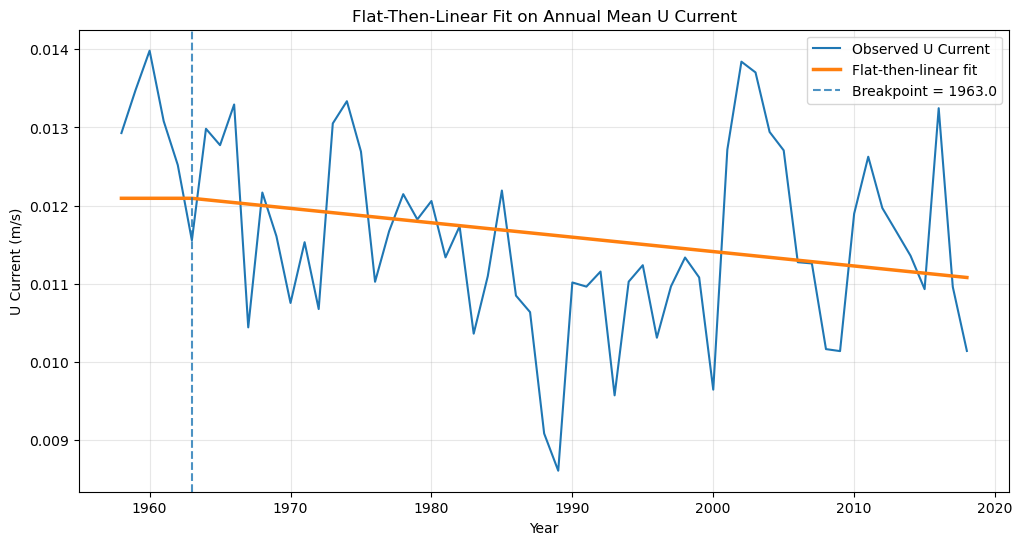


Found 798 files for Potential Temperature
    year  Potential Temperature
0   1958              20.584044
1   1959              20.410537
2   1960              20.945526
3   1961              20.938600
4   1962              20.656470
..   ...                    ...
56  2014              20.908359
57  2015              21.027251
58  2016              20.922402
59  2017              20.989469
60  2018              21.357321

[61 rows x 2 columns]

Optimised breakpoint year: 1981.25 ± 5.24
Flat baseline: 20.49931 ± 0.04418 °C
Post-break slope: 0.01609 ± 0.00333 °C/year
R²: 0.4706


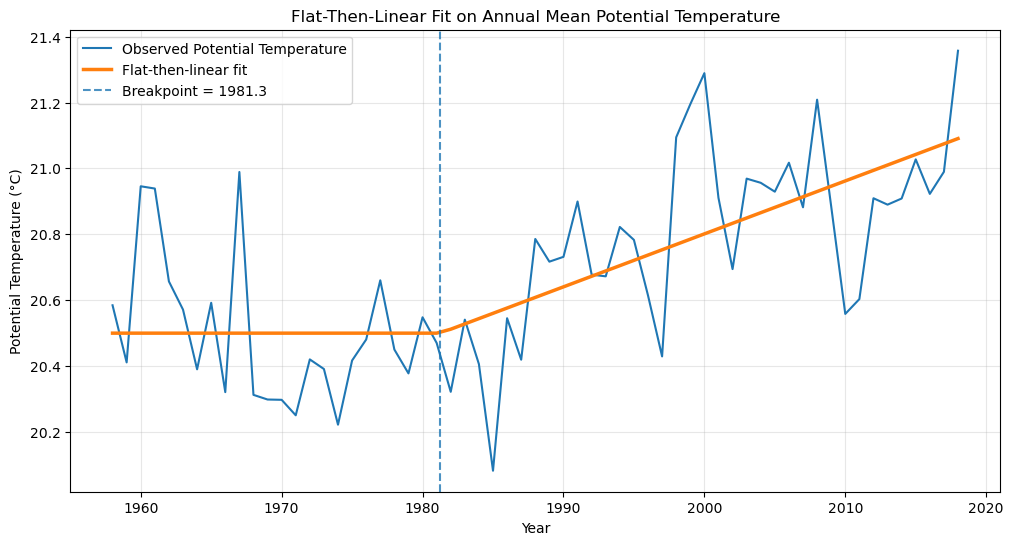


Found 798 files for Net Downward Heat Flux
    year  Net Downward Heat Flux
0   1958              -19.790198
1   1959              -31.537986
2   1960              -24.450588
3   1961              -39.681034
4   1962              -26.672628
..   ...                     ...
60  2018              -47.070619
61  2019              -34.386994
62  2020              -36.289087
63  2021              -39.838994
64  2022               13.918194

[65 rows x 2 columns]

Optimised breakpoint year: 1974.00 ± 62.34
Flat baseline: -29.97013 ± 2.11605 W/m²
Post-break slope: 0.05326 ± 0.09090 W/m²/year
R²: 0.0100


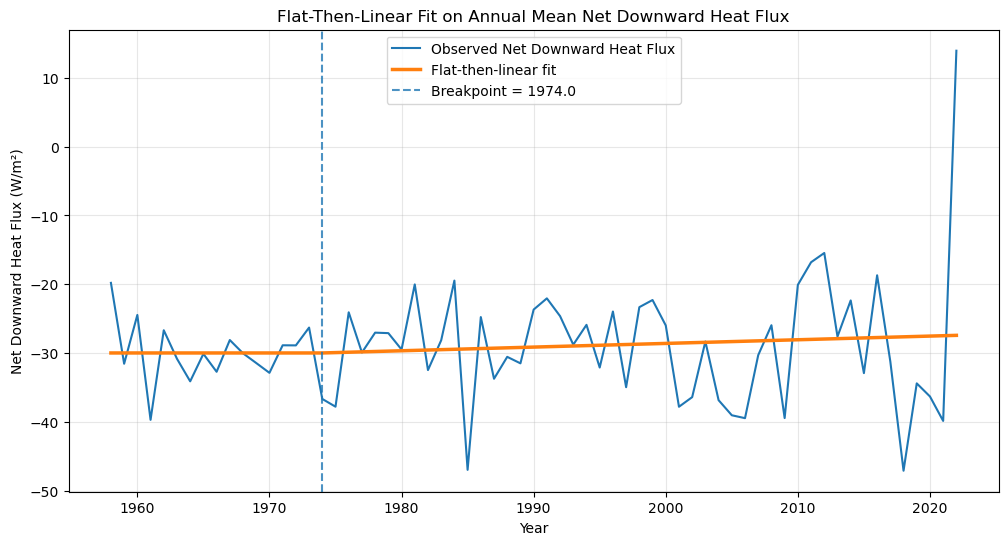

In [19]:
all_results = {}

for var in VARIABLES:
    try:
        df, fit, cov = flat_piecewise_variable_analysis(
            variable_token=var["token"],
            variable_label=var["label"],
            units=var["units"],
            break_guess=var["break_guess"]
        )

        all_results[var["label"]] = {
            "data": df,
            "fit": fit,
            "covariance": cov,
            "units": var["units"]
        }

    except Exception as e:
        print(f"\nFAILED: {var['label']}")
        print(e)

In [20]:
era5_path = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5")

In [21]:
ERA5_VARIABLES = [
    {
        "file": "runoff_full.nc",
        "var_name": None,   # auto-detect
        "label": "Runoff",
        "units": "m",
        "break_guess": 1975
    },
    {
        "file": "sst.nc",
        "var_name": None,
        "label": "ERA5 SST",
        "units": "°C",
        "break_guess": 1975
    },
    {
        "file": "u10_v10.nc",
        "var_name": "u10",
        "label": "10 m U Wind",
        "units": "m/s",
        "break_guess": 1975
    },
    {
        "file": "u10_v10.nc",
        "var_name": "v10",
        "label": "10 m V Wind",
        "units": "m/s",
        "break_guess": 1975
    },
    {
        "file": "all_others.nc",
        "var_name": None,   # this will loop through all variables inside
        "label": "ALL_VARIABLES_IN_FILE",
        "units": "",
        "break_guess": 1975
    }
]

In [22]:
def flat_piecewise_era5_analysis(
    file_name,
    variable_label,
    units,
    var_name=None,
    start_year=1958,
    end_year=2023,
    break_guess=1975
):
    file_path = era5_path / file_name
    print(f"\nOpening {file_path}")

    ds = xr.open_dataset(file_path)

    if var_name is None:
        var_name = list(ds.data_vars)[0]

    print(f"Using variable: {var_name}")

    var = ds[var_name]

    # Find time coordinate
    time_dim = None
    for possible_time in ["time", "valid_time", "date"]:
        if possible_time in var.coords or possible_time in var.dims:
            time_dim = possible_time
            break

    if time_dim is None:
        raise ValueError("No recognised time coordinate found")

    # Find lat/lon coordinates
    if "latitude" in ds:
        lat = ds["latitude"]
        lon = ds["longitude"]
    elif "lat" in ds:
        lat = ds["lat"]
        lon = ds["lon"]
    else:
        raise ValueError("No recognised lat/lon coordinates found")

    lon = xr.where(lon > 180, lon - 360, lon)

    # Subset region
    if lat[0] > lat[-1]:
        var_box = var.sel(
            latitude=slice(LAT_MAX, LAT_MIN),
            longitude=slice(LON_MIN, LON_MAX)
        )
    else:
        var_box = var.sel(
            latitude=slice(LAT_MIN, LAT_MAX),
            longitude=slice(LON_MIN, LON_MAX)
        )

    # Convert Kelvin to Celsius for temperature-like variables
    if any(word in variable_label.lower() for word in ["sst", "temperature", "temp"]):
        if float(var_box.mean(skipna=True)) > 100:
            var_box = var_box - 273.15

    # Monthly/annual mean over space
    spatial_dims = [
        d for d in var_box.dims
        if d != time_dim
    ]

    ts = var_box.mean(dim=spatial_dims, skipna=True)

    df = ts.to_dataframe(name=variable_label).reset_index()
    df["year"] = pd.to_datetime(df[time_dim]).dt.year

    annual_df = (
        df.groupby("year", as_index=False)[variable_label]
        .mean()
        .sort_values("year")
    )

    annual_df = annual_df[
        (annual_df["year"] >= start_year) &
        (annual_df["year"] <= end_year)
    ]

    annual_df = annual_df.replace([np.inf, -np.inf], np.nan).dropna()
    annual_df = annual_df[np.abs(annual_df[variable_label]) < 1e10]

    years_clean = annual_df["year"].values.astype(float)
    values_clean = annual_df[variable_label].values.astype(float)

    print(annual_df)

    c_guess = np.mean(values_clean[years_clean < break_guess])
    m_guess = 0.01
    p0 = [c_guess, m_guess, break_guess]

    lower_bounds = [
        np.min(values_clean) - abs(np.min(values_clean)),
        -np.inf,
        start_year + 5
    ]

    upper_bounds = [
        np.max(values_clean) + abs(np.max(values_clean)),
        np.inf,
        end_year - 5
    ]

    popt, pcov = curve_fit(
        flat_then_linear,
        years_clean,
        values_clean,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=100000
    )

    c_fit, m_fit, break_fit = popt
    perr = np.sqrt(np.diag(pcov))
    c_err, m_err, break_err = perr

    y_hat = flat_then_linear(years_clean, c_fit, m_fit, break_fit)

    residuals = values_clean - y_hat
    rss = np.sum(residuals**2)
    tss = np.sum((values_clean - np.mean(values_clean))**2)
    r2 = 1 - rss / tss

    print(f"\nOptimised breakpoint year: {break_fit:.2f} ± {break_err:.2f}")
    print(f"Flat baseline: {c_fit:.5f} ± {c_err:.5f} {units}")
    print(f"Post-break slope: {m_fit:.5f} ± {m_err:.5f} {units}/year")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(years_clean, values_clean, linewidth=1.5, label=f"Observed {variable_label}")
    plt.plot(years_clean, y_hat, linewidth=2.5, label="Flat-then-linear fit")
    plt.axvline(
        break_fit,
        linestyle="--",
        alpha=0.8,
        label=f"Breakpoint = {break_fit:.1f}"
    )

    plt.title(f"Flat-Then-Linear Fit on Annual Mean {variable_label}")
    plt.xlabel("Year")
    plt.ylabel(f"{variable_label} ({units})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    ds.close()

    return annual_df, popt, pcov


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\runoff_full.nc
Using variable: ro
    year  Runoff
18  1958     0.0
19  1959     0.0
20  1960     0.0
21  1961     0.0
22  1962     0.0
..   ...     ...
79  2019     0.0
80  2020     0.0
81  2021     0.0
82  2022     0.0
83  2023     0.0

[66 rows x 2 columns]

FAILED: runoff_full.nc / Runoff
Each lower bound must be strictly less than each upper bound.

Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\sst.nc
Using variable: sst
    year   ERA5 SST
18  1958  20.558050
19  1959  20.425785
20  1960  20.939039
21  1961  21.084486
22  1962  20.708437
..   ...        ...
79  2019  21.294952
80  2020  21.432709
81  2021  21.615904
82  2022  21.481867
83  2023  21.660456

[66 rows x 2 columns]

Optimised breakpoint year: 1981.67 ± 3.66
Flat baseline: 20.61637 ± 0.04137 °C
Post-break slope: 0.02040 ± 0.00258 °C/year
R²: 0.6731


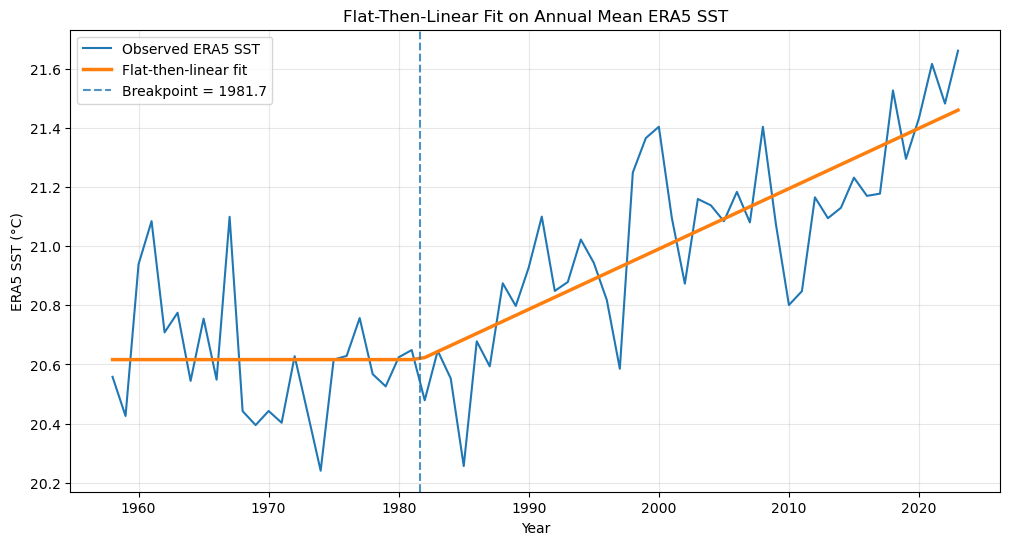


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\u10_v10.nc
Using variable: u10
Empty DataFrame
Columns: [year, 10 m U Wind]
Index: []

FAILED: u10_v10.nc / 10 m U Wind
zero-size array to reduction operation minimum which has no identity

Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\u10_v10.nc
Using variable: v10
Empty DataFrame
Columns: [year, 10 m V Wind]
Index: []

FAILED: u10_v10.nc / 10 m V Wind
zero-size array to reduction operation minimum which has no identity

Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: d2m


C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


    year    ERA5 d2m
8   1958  286.125885
9   1959  285.613831
10  1960  286.011139
11  1961  286.197784
12  1962  285.741089
..   ...         ...
69  2019  286.661896
70  2020  286.138763
71  2021  286.977173
72  2022  286.406464
73  2023  286.561981

[66 rows x 2 columns]

Optimised breakpoint year: 1977.71 ± 8.71
Flat baseline: 285.79782 ± 0.08316 
Post-break slope: 0.01573 ± 0.00413 /year
R²: 0.3035


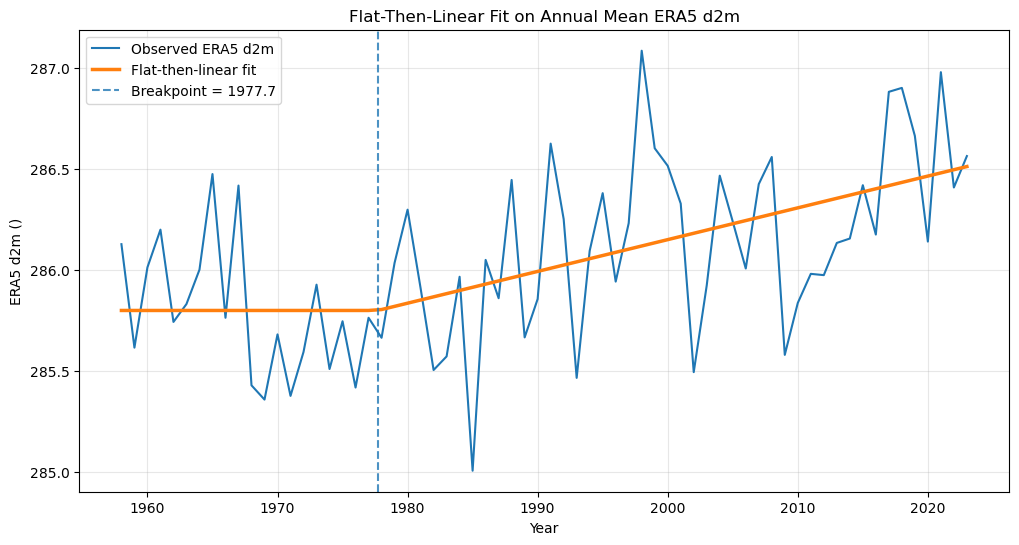


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: t2m
    year    ERA5 t2m
8   1958  289.883392
9   1959  289.644958
10  1960  289.904999
11  1961  290.259796
12  1962  289.797607
..   ...         ...
69  2019  290.613068
70  2020  290.285187
71  2021  290.843292
72  2022  290.507111
73  2023  290.635590

[66 rows x 2 columns]

Optimised breakpoint year: 1978.00 ± 7.15
Flat baseline: 289.77703 ± 0.07114 
Post-break slope: 0.01703 ± 0.00374 /year
R²: 0.3965


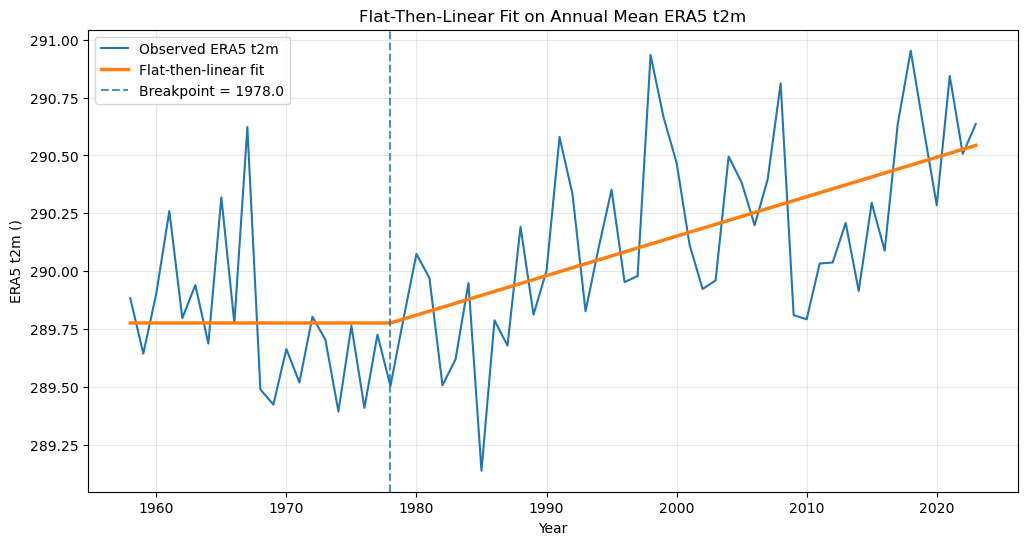


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: skt
    year    ERA5 skt
8   1958  290.272278
9   1959  290.034943
10  1960  290.313721
11  1961  290.597260
12  1962  290.048096
..   ...         ...
69  2019  290.859253
70  2020  290.815552
71  2021  291.197388
72  2022  290.869995
73  2023  290.887634

[66 rows x 2 columns]

Optimised breakpoint year: 1981.49 ± 8.80
Flat baseline: 290.24882 ± 0.07441 
Post-break slope: 0.01534 ± 0.00464 /year
R²: 0.2661


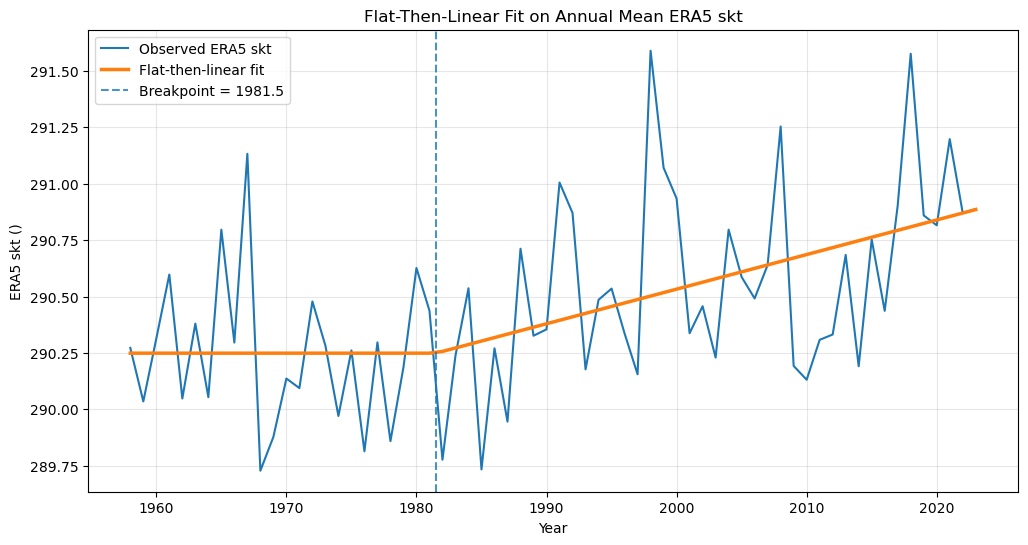


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: stl1
    year   ERA5 stl1
8   1958  290.806183
9   1959  290.657867
10  1960  290.842316
11  1961  291.233002
12  1962  290.577057
..   ...         ...
69  2019  291.366760
70  2020  291.411957
71  2021  291.764374
72  2022  291.474121
73  2023  291.428253

[66 rows x 2 columns]

Optimised breakpoint year: 1978.00 ± 11.01
Flat baseline: 290.82713 ± 0.08704 
Post-break slope: 0.01353 ± 0.00458 /year
R²: 0.2169


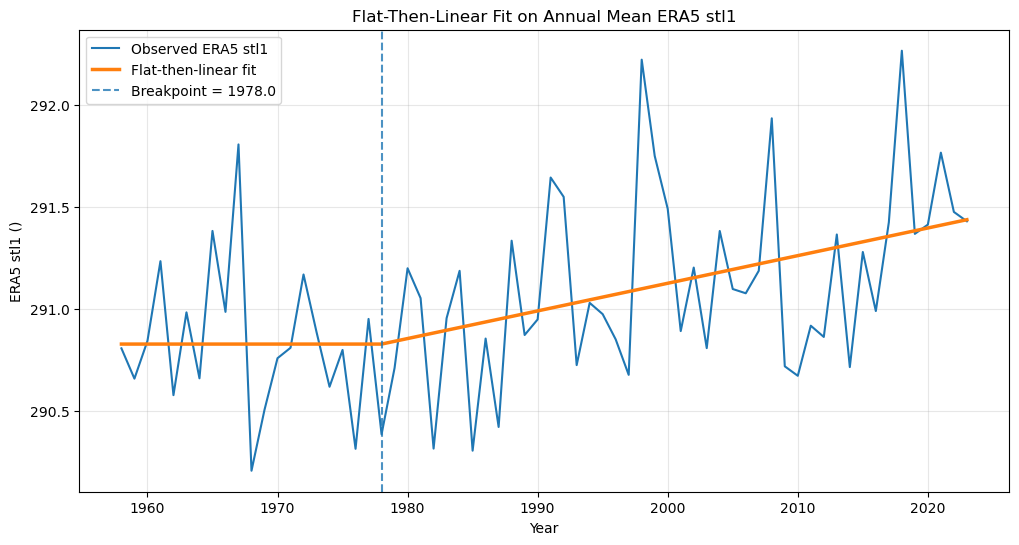


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: stl2
    year   ERA5 stl2
8   1958  290.774506
9   1959  290.564606
10  1960  290.772247
11  1961  291.150482
12  1962  290.527649
..   ...         ...
69  2019  291.333038
70  2020  291.336975
71  2021  291.690826
72  2022  291.417358
73  2023  291.376068

[66 rows x 2 columns]

Optimised breakpoint year: 1978.00 ± 10.38
Flat baseline: 290.75242 ± 0.08393 
Post-break slope: 0.01384 ± 0.00441 /year
R²: 0.2375


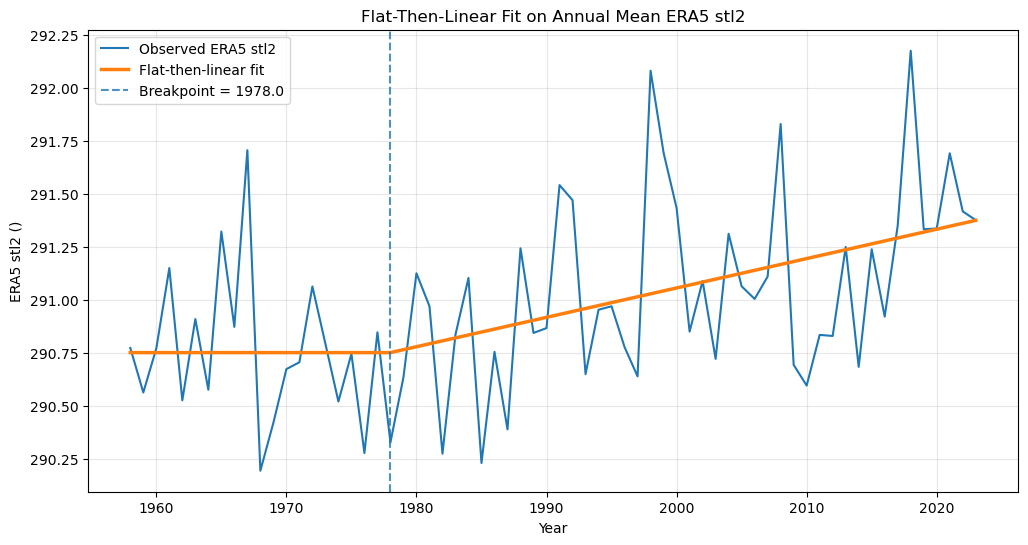


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: stl3
    year   ERA5 stl3
8   1958  290.749329
9   1959  290.469421
10  1960  290.688568
11  1961  291.092072
12  1962  290.473419
..   ...         ...
69  2019  291.308075
70  2020  291.305573
71  2021  291.593323
72  2022  291.401093
73  2023  291.306519

[66 rows x 2 columns]

Optimised breakpoint year: 1978.00 ± 9.70
Flat baseline: 290.67501 ± 0.08072 
Post-break slope: 0.01425 ± 0.00425 /year
R²: 0.2632


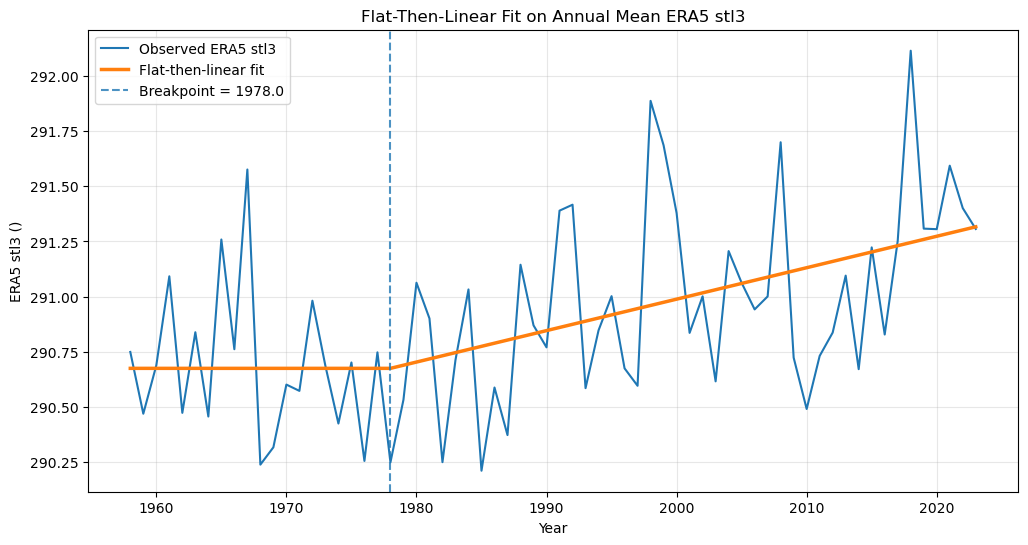


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: stl4
    year   ERA5 stl4
8   1958  290.729095
9   1959  290.422394
10  1960  290.596497
11  1961  291.059235
12  1962  290.426605
..   ...         ...
69  2019  291.299194
70  2020  291.317932
71  2021  291.471741
72  2022  291.438599
73  2023  291.231232

[66 rows x 2 columns]

Optimised breakpoint year: 1978.00 ± 9.22
Flat baseline: 290.61478 ± 0.07833 
Post-break slope: 0.01454 ± 0.00412 /year
R²: 0.2833


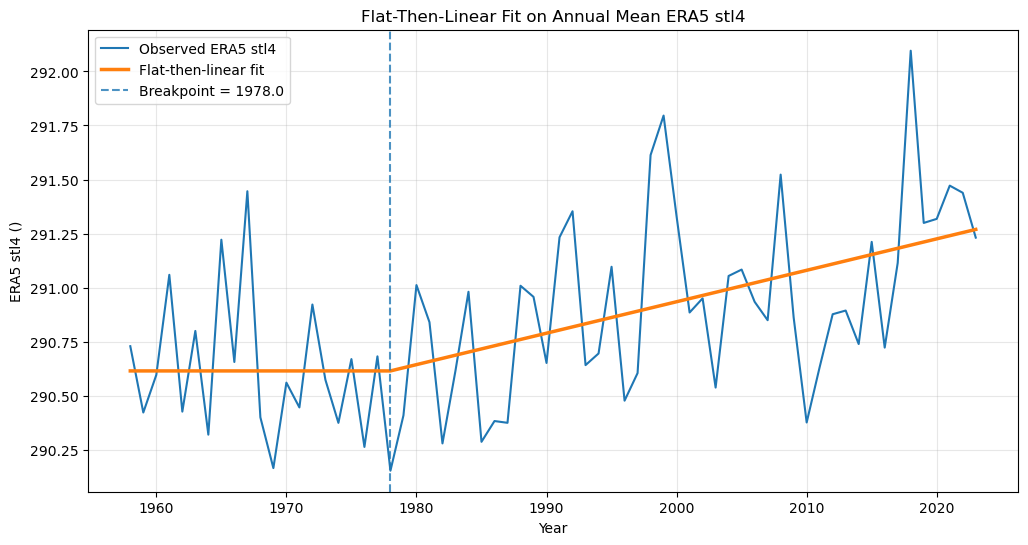


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: src
    year  ERA5 src
8   1958  0.000032
9   1959  0.000031
10  1960  0.000035
11  1961  0.000036
12  1962  0.000032
..   ...       ...
69  2019  0.000029
70  2020  0.000021
71  2021  0.000040
72  2022  0.000027
73  2023  0.000031

[66 rows x 2 columns]

Optimised breakpoint year: 1963.00 ± 43.41
Flat baseline: 0.00003 ± 0.00000 
Post-break slope: -0.00000 ± 0.00000 /year
R²: 0.0437


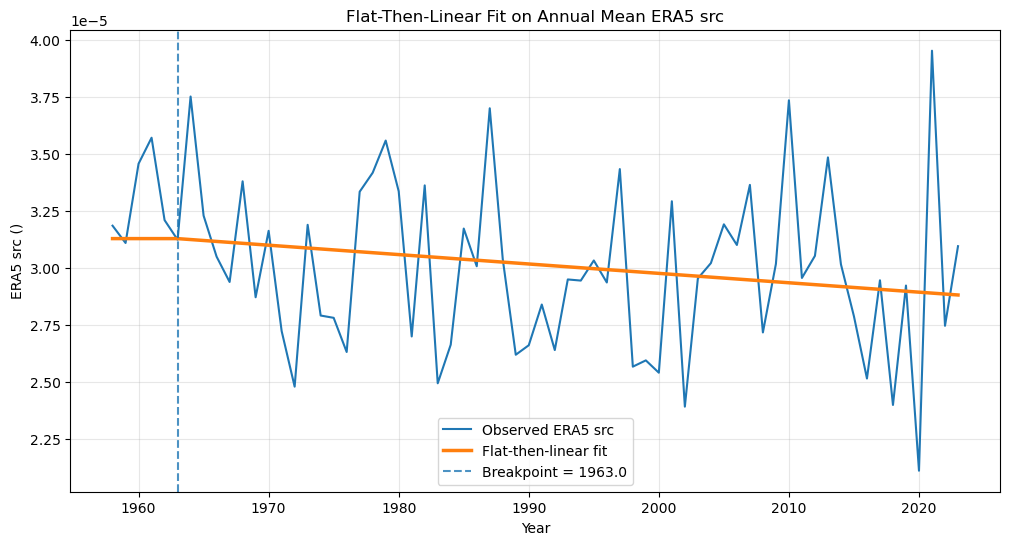


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: swvl1
    year  ERA5 swvl1
8   1958    0.207797
9   1959    0.204342
10  1960    0.219104
11  1961    0.217149
12  1962    0.210749
..   ...         ...
69  2019    0.209647
70  2020    0.182711
71  2021    0.216385
72  2022    0.201330
73  2023    0.211068

[66 rows x 2 columns]

Optimised breakpoint year: 1992.00 ± 36.30
Flat baseline: 0.20078 ± 0.00216 
Post-break slope: 0.00014 ± 0.00026 /year
R²: 0.0130


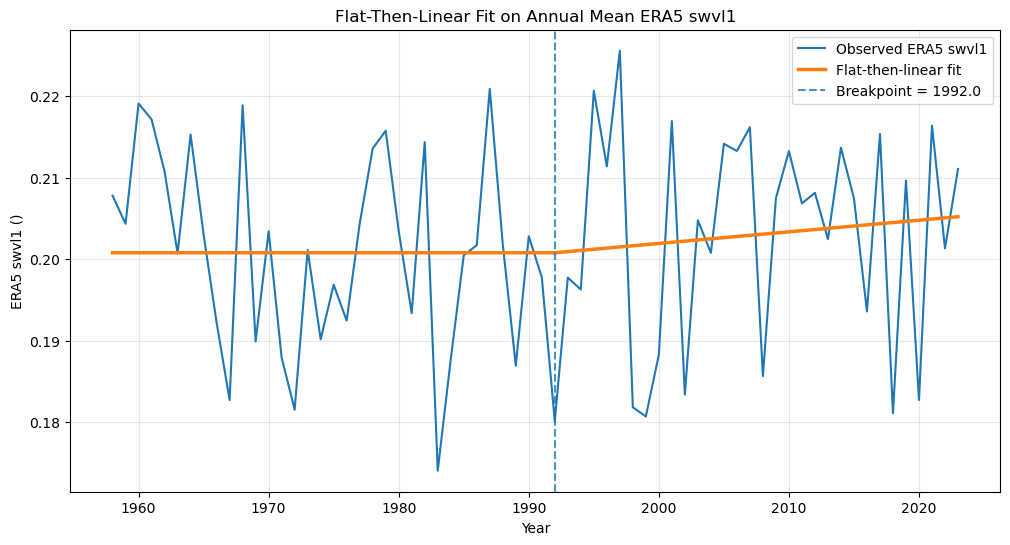


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: swvl2
    year  ERA5 swvl2
8   1958    0.227311
9   1959    0.227599
10  1960    0.239311
11  1961    0.237381
12  1962    0.231809
..   ...         ...
69  2019    0.229580
70  2020    0.208218
71  2021    0.236483
72  2022    0.223024
73  2023    0.233060

[66 rows x 2 columns]

Optimised breakpoint year: 1992.00 ± 30.47
Flat baseline: 0.22257 ± 0.00184 
Post-break slope: 0.00014 ± 0.00022 /year
R²: 0.0184


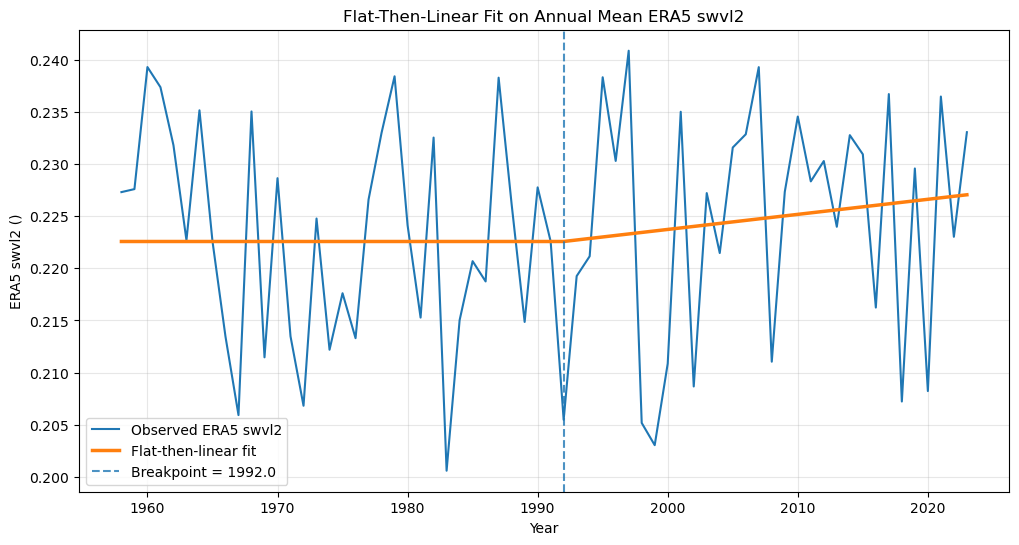


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: swvl3
    year  ERA5 swvl3
8   1958    0.223807
9   1959    0.232964
10  1960    0.233658
11  1961    0.233877
12  1962    0.234357
..   ...         ...
69  2019    0.228653
70  2020    0.215375
71  2021    0.235770
72  2022    0.225815
73  2023    0.240143

[66 rows x 2 columns]

Optimised breakpoint year: 1985.00 ± 25.59
Flat baseline: 0.22526 ± 0.00199 
Post-break slope: 0.00016 ± 0.00016 /year
R²: 0.0363


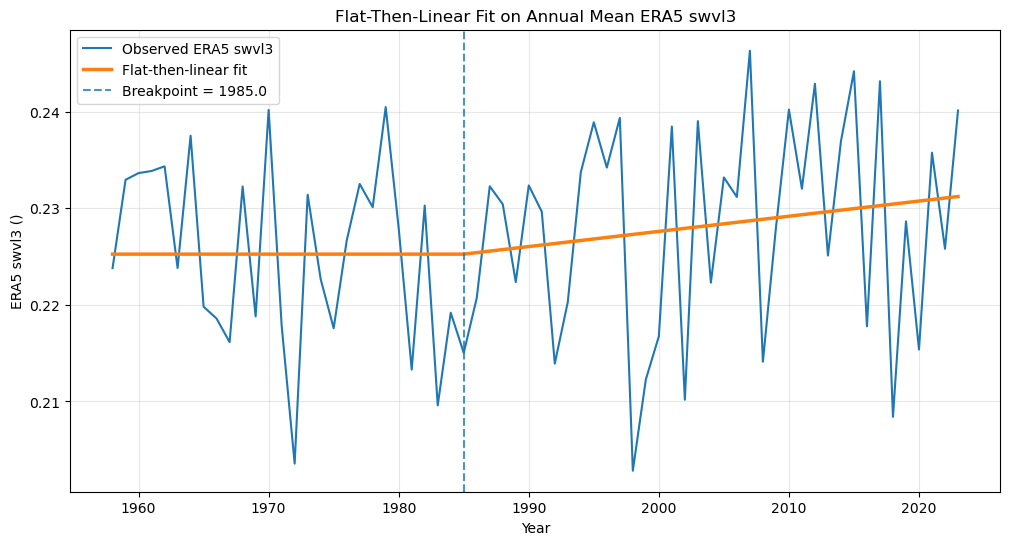


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: swvl4
    year  ERA5 swvl4
8   1958    0.261016
9   1959    0.264626
10  1960    0.266658
11  1961    0.270791
12  1962    0.268510
..   ...         ...
69  2019    0.262650
70  2020    0.253468
71  2021    0.271927
72  2022    0.262213
73  2023    0.270685

[66 rows x 2 columns]

Optimised breakpoint year: 1963.00 ± 141.22
Flat baseline: 0.26374 ± 0.00291 
Post-break slope: -0.00002 ± 0.00005 /year
R²: 0.0043


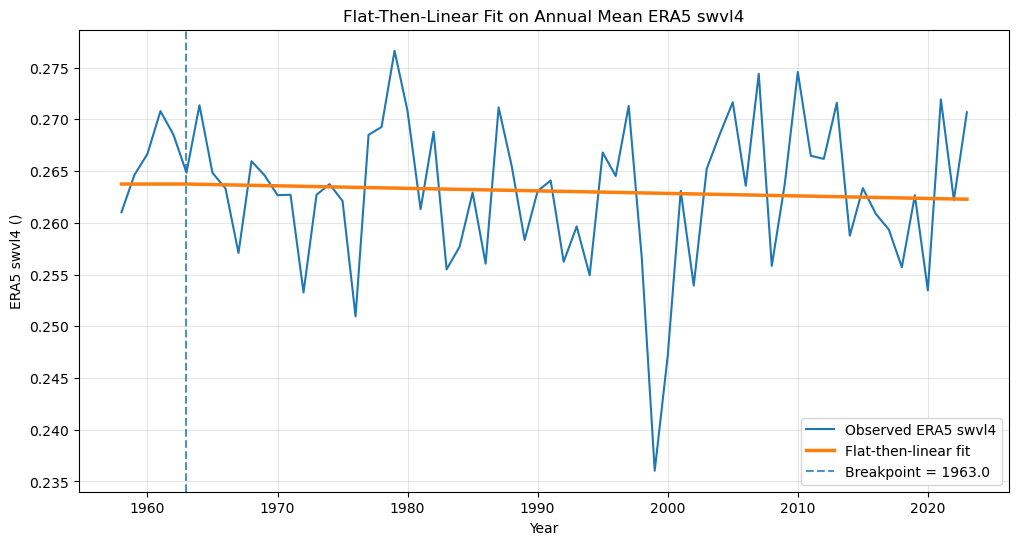


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: u10
    year  ERA5 u10
8   1958  2.687824
9   1959  3.301858
10  1960  3.356841
11  1961  3.413451
12  1962  1.766419
..   ...       ...
69  2019  2.778455
70  2020  1.777539
71  2021  2.808049
72  2022  2.424852
73  2023  2.448805

[66 rows x 2 columns]

Optimised breakpoint year: 2011.57 ± 10.80
Flat baseline: 2.16121 ± 0.09684 
Post-break slope: 0.03887 ± 0.05951 /year
R²: 0.0226


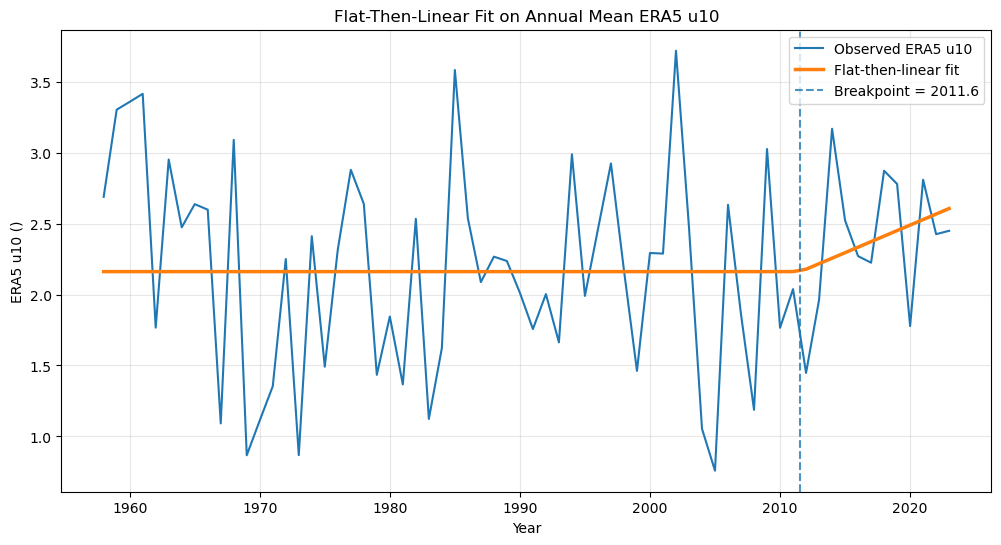


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: v10
    year  ERA5 v10
8   1958  1.213128
9   1959  1.135812
10  1960  0.808275
11  1961  1.384263
12  1962  1.375894
..   ...       ...
69  2019  2.012362
70  2020  0.315696
71  2021  1.495840
72  2022  0.295184
73  2023  1.777035

[66 rows x 2 columns]

Optimised breakpoint year: 1963.00 ± 115.81
Flat baseline: 1.02401 ± 0.22321 
Post-break slope: -0.00229 ± 0.00408 /year
R²: 0.0064


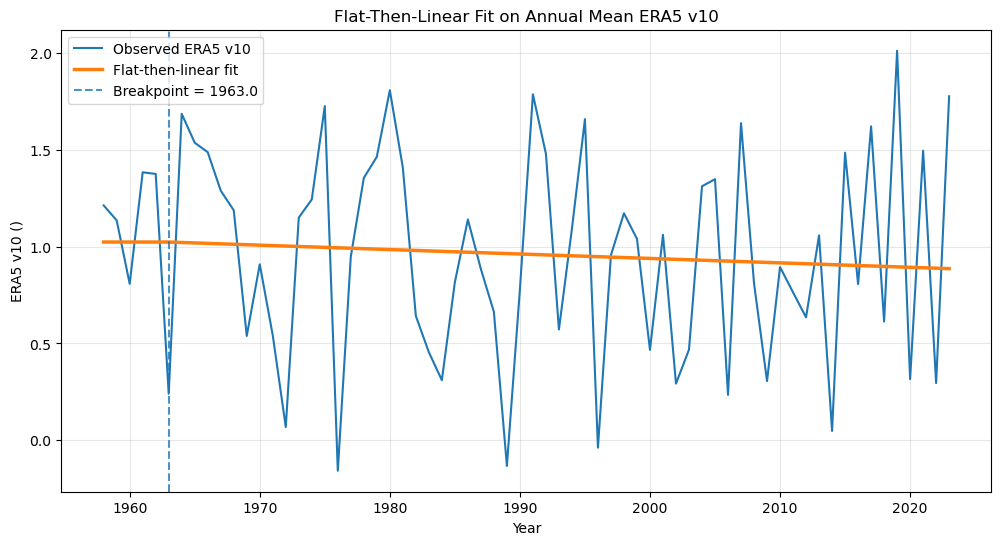


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: sp
    year        ERA5 sp
8   1958  100317.773438
9   1959  100562.429688
10  1960  100397.164062
11  1961  100431.335938
12  1962  100579.937500
..   ...            ...
69  2019  100511.023438
70  2020  100766.210938
71  2021  100443.601562
72  2022  100609.539062
73  2023  100416.289062

[66 rows x 2 columns]

Optimised breakpoint year: 1963.00 ± 63.66
Flat baseline: 100492.81380 ± 54.60955 
Post-break slope: 1.01862 ± 0.99717 /year
R²: 0.0208


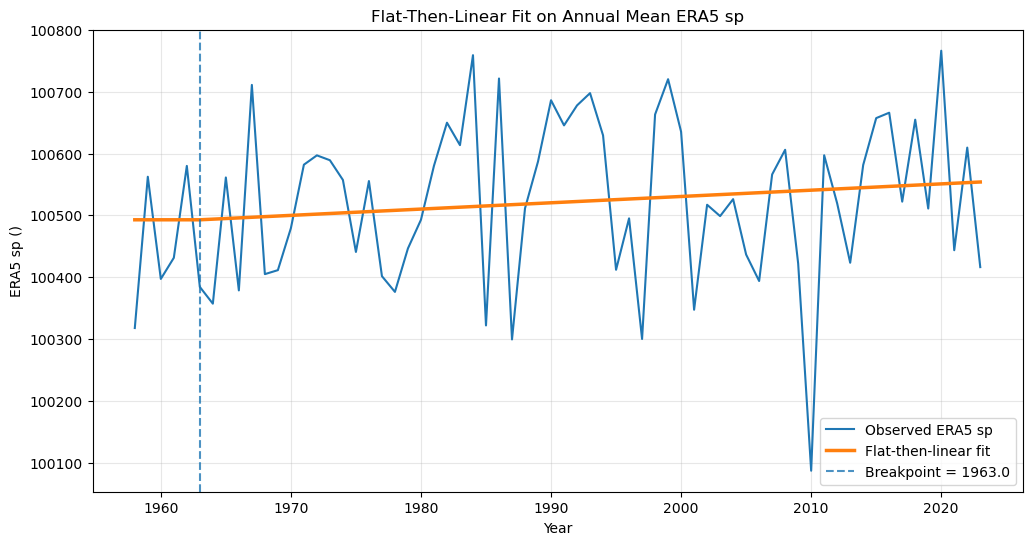


Opening C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc
Using variable: tp
    year   ERA5 tp
8   1958  0.002871
9   1959  0.003126
10  1960  0.003676
11  1961  0.004057
12  1962  0.003154
..   ...       ...
69  2019  0.003321
70  2020  0.002048
71  2021  0.004585
72  2022  0.002218
73  2023  0.001827

[66 rows x 2 columns]

Optimised breakpoint year: 1974.28 ± 47.52
Flat baseline: 0.00314 ± 0.00013 
Post-break slope: -0.00000 ± 0.00001 /year
R²: 0.0171


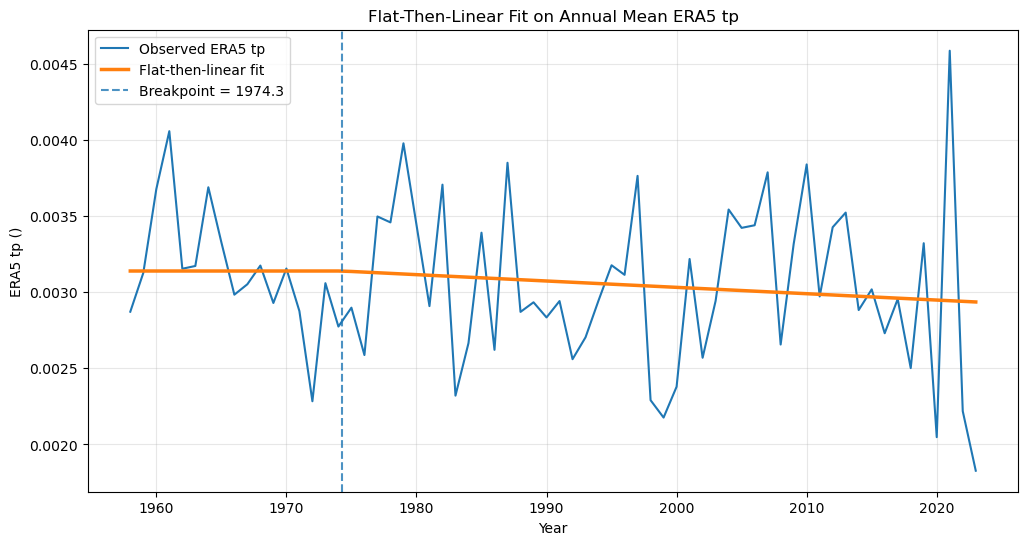

In [23]:
era5_results = {}

for item in ERA5_VARIABLES:
    try:
        file_path = era5_path / item["file"]

        if item["label"] == "ALL_VARIABLES_IN_FILE":
            ds_temp = xr.open_dataset(file_path)
            variable_names = list(ds_temp.data_vars)
            ds_temp.close()

            for v in variable_names:
                label = f"ERA5 {v}"

                df, fit, cov = flat_piecewise_era5_analysis(
                    file_name=item["file"],
                    var_name=v,
                    variable_label=label,
                    units=item["units"],
                    break_guess=item["break_guess"]
                )

                era5_results[label] = {
                    "data": df,
                    "fit": fit,
                    "covariance": cov,
                    "units": item["units"],
                    "file": item["file"],
                    "var_name": v
                }

        else:
            df, fit, cov = flat_piecewise_era5_analysis(
                file_name=item["file"],
                var_name=item["var_name"],
                variable_label=item["label"],
                units=item["units"],
                break_guess=item["break_guess"]
            )

            era5_results[item["label"]] = {
                "data": df,
                "fit": fit,
                "covariance": cov,
                "units": item["units"],
                "file": item["file"],
                "var_name": item["var_name"]
            }

    except Exception as e:
        print(f"\nFAILED: {item['file']} / {item['label']}")
        print(e)

In [24]:
# summary table
summary_records = []

# ORAS5
for label, result in all_results.items():

    fit = result["fit"]
    cov = result["covariance"]
    errors = np.sqrt(np.diag(cov))

    summary_records.append({
        "Dataset": "ORAS5",
        "Variable": label,
        "Units": result["units"],
        "Breakpoint Year": fit[2],
        "Breakpoint Error": errors[2],
        "Baseline": fit[0],
        "Baseline Error": errors[0],
        "Slope": fit[1],
        "Slope Error": errors[1]
    })

# ERA5
for label, result in era5_results.items():

    fit = result["fit"]
    cov = result["covariance"]
    errors = np.sqrt(np.diag(cov))

    summary_records.append({
        "Dataset": "ERA5",
        "Variable": label,
        "Units": result["units"],
        "Breakpoint Year": fit[2],
        "Breakpoint Error": errors[2],
        "Baseline": fit[0],
        "Baseline Error": errors[0],
        "Slope": fit[1],
        "Slope Error": errors[1]
    })

summary_df = (
    pd.DataFrame(summary_records)
    .sort_values("Breakpoint Error")
    .reset_index(drop=True)
)

summary_df

,Dataset,Variable,Units,Breakpoint Year,Breakpoint Error,Baseline,Baseline Error,Slope,Slope Error
0,ERA5,ERA5 SST,°C,1981.666277,3.660930,20.616365,0.041365,2.039981e-02,2.579756e-03
1,ORAS5,Potential Temperature,°C,1981.254855,5.244988,20.499310,0.044179,1.608765e-02,3.332453e-03
2,ORAS5,SST,°C,1980.369344,5.848560,20.500601,0.048736,1.493427e-02,2.975459e-03
3,ERA5,ERA5 t2m,,1978.000012,7.150424,289.777025,0.071141,1.703121e-02,3.742052e-03
4,ERA5,ERA5 d2m,,1977.709631,8.713744,285.797818,0.083157,1.572767e-02,4.130192e-03
5,ERA5,ERA5 skt,,1981.494957,8.797983,290.248824,0.074412,1.533530e-02,4.640741e-03
6,ERA5,ERA5 stl4,,1978.000000,9.220733,290.614783,0.078332,1.454221e-02,4.118835e-03
7,ERA5,ERA5 stl3,,1978.000139,9.696304,290.675014,0.080718,1.425007e-02,4.245775e-03
8,ORAS5,Salinity,PSU,1972.999983,9.956933,36.412942,0.016091,2.499888e-03,7.105708e-04
9,ERA5,ERA5 stl2,,1978.000106,10.384243,290.752419,0.083930,1.383556e-02,4.414741e-03
